<a href="https://colab.research.google.com/github/weathon/neg/blob/main/NAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!git clone https://github.com/ChenDarYen/Normalized-Attention-Guidance.git

fatal: destination path 'Normalized-Attention-Guidance' already exists and is not an empty directory.


In [17]:
!pip install image-reward clip -qq

In [18]:
!pip install -r Normalized-Attention-Guidance/requirements.txt -qq

In [19]:
import sys
sys.path.append("Normalized-Attention-Guidance")

In [20]:
from huggingface_hub import login

In [21]:
import ImageReward as reward
reward_model = reward.load("ImageReward-v1.0")

load checkpoint from /root/.cache/ImageReward/ImageReward.pt
checkpoint loaded


In [22]:
import math
from typing import Optional

import torch
import torch.nn.functional as F

from diffusers.models.attention_processor import Attention
from diffusers.models.embeddings import apply_rotary_emb
import pylab
import random

class NAGFluxAttnProcessor2_0:
    """Attention processor used typically in processing the SD3-like self-attention projections."""

    def __init__(
            self,
            nag_scale: float = 1.0,
            nag_tau=2.5,
            nag_alpha=0.25,
            encoder_hidden_states_length: int = None,
    ):
        if not hasattr(F, "scaled_dot_product_attention"):
            raise ImportError("FluxAttnProcessor2_0 requires PyTorch 2.0, to use it, please upgrade PyTorch to 2.0.")
        self.nag_scale = nag_scale
        self.nag_tau = nag_tau
        self.nag_alpha = nag_alpha
        self.encoder_hidden_states_length = encoder_hidden_states_length

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.FloatTensor,
        encoder_hidden_states: torch.FloatTensor = None,
        attention_mask: Optional[torch.FloatTensor] = None,
        image_rotary_emb: Optional[torch.Tensor] = None,
    ) -> torch.FloatTensor:
        batch_size, _, _ = hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        # print(hidden_states.shape)
        if self.nag_scale > 1.:
            if encoder_hidden_states is not None:
                assert len(hidden_states) == batch_size * 0.5
            apply_guidance = True
        else:
            apply_guidance = False

        # `sample` projections.
        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        # attention
        if apply_guidance and encoder_hidden_states is not None:
            query = query.tile(2, 1, 1)
            key = key.tile(2, 1, 1)
            value = value.tile(2, 1, 1)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        # the attention in FluxSingleTransformerBlock does not use `encoder_hidden_states`
        if encoder_hidden_states is not None:
            # `context` projections.
            encoder_hidden_states_query_proj = attn.add_q_proj(encoder_hidden_states)
            encoder_hidden_states_key_proj = attn.add_k_proj(encoder_hidden_states)
            encoder_hidden_states_value_proj = attn.add_v_proj(encoder_hidden_states)

            encoder_hidden_states_query_proj = encoder_hidden_states_query_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_key_proj = encoder_hidden_states_key_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_value_proj = encoder_hidden_states_value_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)

            if attn.norm_added_q is not None:
                encoder_hidden_states_query_proj = attn.norm_added_q(encoder_hidden_states_query_proj)
            if attn.norm_added_k is not None:
                encoder_hidden_states_key_proj = attn.norm_added_k(encoder_hidden_states_key_proj)

            query = torch.cat([encoder_hidden_states_query_proj, query], dim=2)
            key = torch.cat([encoder_hidden_states_key_proj, key], dim=2)
            value = torch.cat([encoder_hidden_states_value_proj, value], dim=2)

            encoder_hidden_states_length = encoder_hidden_states.shape[1]

        else:
            assert self.encoder_hidden_states_length is not None
            encoder_hidden_states_length = self.encoder_hidden_states_length

        if image_rotary_emb is not None:
            query = apply_rotary_emb(query, image_rotary_emb)
            key = apply_rotary_emb(key, image_rotary_emb)

        if not apply_guidance:
            hidden_states = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
            hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)

        else:
            origin_batch_size = batch_size // 2
            query, query_negative = torch.chunk(query, 2, dim=0)
            key, key_negative = torch.chunk(key, 2, dim=0)
            value, value_negative = torch.chunk(value, 2, dim=0)

            if encoder_hidden_states is not None:
              encoder_neg_query = query_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_key = key_negative[:,:,:encoder_hidden_states_length]
              encoder_neg_value = value_negative[:,:,:encoder_hidden_states_length]
              query_pos_neg = torch.cat([encoder_neg_query, query], dim=2)
              key_pos_neg = torch.cat([encoder_neg_key, key], dim=2)
              value_pos_neg = torch.cat([- 1.8 * encoder_neg_value, value], dim=2)

              hidden_states_regular = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False)
              hidden_states_regular = hidden_states_regular.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
              hidden_states_regular = hidden_states_regular.to(query.dtype)

            else:
              query_pos_neg, key_pos_neg, value_pos_neg = query, key, value

            hidden_state_pure_negative = F.scaled_dot_product_attention(query_negative, key_negative, value_negative, dropout_p=0.0, is_causal=False)
            hidden_state_pure_negative = hidden_state_pure_negative.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
            hidden_state_pure_negative = hidden_state_pure_negative.to(query.dtype)

            hidden_states = F.scaled_dot_product_attention(query_pos_neg, key_pos_neg, value_pos_neg, dropout_p=0.0, is_causal=False)
            hidden_states = hidden_states.transpose(1, 2).reshape(origin_batch_size, -1, attn.heads * head_dim)
            hidden_states = hidden_states.to(query.dtype)


            if encoder_hidden_states is not None:
              # hidden_states[:,encoder_hidden_states_length:2*encoder_hidden_states_length] -= hidden_states[:,:encoder_hidden_states_length]
              hidden_states = hidden_states[:,encoder_hidden_states_length:]
              assert hidden_states_regular.shape == hidden_states.shape == hidden_state_pure_negative.shape

        if encoder_hidden_states is not None:
            encoder_hidden_states, hidden_states = (
                hidden_states[:, : encoder_hidden_states.shape[1]],
                hidden_states[:, encoder_hidden_states.shape[1] :],
            )

            if apply_guidance:
                encoder_hidden_states_regular, hidden_states_regular = (
                    hidden_states_regular[:, : encoder_hidden_states.shape[1]],
                    hidden_states_regular[:, encoder_hidden_states.shape[1]:],
                )

                encoder_hidden_state_pure_negative, hidden_state_pure_negative = (
                    hidden_state_pure_negative[:, : encoder_hidden_states.shape[1]],
                    hidden_state_pure_negative[:, encoder_hidden_states.shape[1]:],
                )

                hidden_states = hidden_states * self.nag_scale - hidden_state_pure_negative * (self.nag_scale - 1)

                norm_positive = torch.norm(hidden_states_regular, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)
                norm_guidance = torch.norm(hidden_states, p=1, dim=-1, keepdim=True).expand(*hidden_states_regular.shape)

                scale = norm_guidance / norm_positive
                hidden_states = hidden_states * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale

                hidden_states = hidden_states * self.nag_alpha + hidden_states_regular * (1 - self.nag_alpha)

                encoder_hidden_states = torch.cat((encoder_hidden_states, encoder_hidden_state_pure_negative), dim=0)
                # encoder_hidden_states = torch.cat((encoder_hidden_states, encoder_hidden_states_regular), dim=0)

            hidden_states = attn.to_out[0](hidden_states)
            hidden_states = attn.to_out[1](hidden_states)

            encoder_hidden_states = attn.to_add_out(encoder_hidden_states)
            # print(hidden_states.shape, encoder_hidden_states.shape)
            return hidden_states, encoder_hidden_states

        else:
            if apply_guidance:
                image_hidden_state_pure_negative = hidden_state_pure_negative[:, encoder_hidden_states_length:]
                image_hidden_states = hidden_states[:, encoder_hidden_states_length:]

                image_hidden_states_guidance = image_hidden_states * self.nag_scale - image_hidden_state_pure_negative * (self.nag_scale - 1)
                norm_positive = torch.norm(image_hidden_states, p=2, dim=-1, keepdim=True).expand(*image_hidden_states.shape)
                norm_guidance = torch.norm(image_hidden_states_guidance, p=2, dim=-1, keepdim=True).expand(*image_hidden_states.shape)

                scale = norm_guidance / norm_positive
                image_hidden_states_guidance = image_hidden_states_guidance * torch.minimum(scale, scale.new_ones(1) * self.nag_tau) / scale
                # scale = torch.nan_to_num(scale, 10)
                # image_hidden_states_guidance[scale > self.nag_tau] = image_hidden_states_guidance[scale > self.nag_tau] / (norm_guidance[scale > self.nag_tau] + 1e-7) * norm_positive[scale > self.nag_tau] * self.nag_tau

                image_hidden_states = image_hidden_states_guidance * self.nag_alpha + image_hidden_states * (1 - self.nag_alpha)

                hidden_state_pure_negative[:, encoder_hidden_states_length:] = image_hidden_states
                hidden_states[:, encoder_hidden_states_length:] = image_hidden_states
                hidden_states = torch.cat((hidden_states, hidden_state_pure_negative), dim=0)
            return hidden_states

In [23]:
import torch
from src.pipeline_flux_nag import NAGFluxPipeline
from src.transformer_flux import NAGFluxTransformer2DModel
from src.attention_flux_nag import NAGFluxAttnProcessor2_0 as NAGFluxAttnProcessor2_0_vanilla

transformer = NAGFluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    subfolder="transformer",
    torch_dtype=torch.bfloat16,
)

if not "pipe" in locals():
  pipe = NAGFluxPipeline.from_pretrained(
      "black-forest-labs/FLUX.1-schnell",
      transformer=transformer,
      torch_dtype=torch.bfloat16,
  )
  pipe.to("cuda")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [24]:
prompts = [
    {
        "pos": "a bathroom in a house",
        "neg": "beautiful"
    },
    {
        "pos": "a living room in a countryside house",
        "neg": "tidy and clean"
    },
    {
        "pos": "a cup of soda in a container",
        "neg": "round cylinder"
    },
    {
        "pos": "a cup of soda in a container",
        "neg": "straw"
    },
    {
        "pos": "a wireless earphone on the table",
        "neg": "plastic"
    },
    {
        "pos": "a pair of shoes on the ground",
        "neg": "fabric"
    },
    {
      "pos": "a human standing in the office with a suit",
      "neg": "a tie"
    },
    {
        "pos": "a human drink soda",
        "neg": "dark liquid"
    },
    {
        "pos": "A fork slices through a soft, fluffy cake, which is beautifully frosted and placed on a fine porcelain plate, illuminated by warm, ambient lighting for a cozy, inviting atmosphere.",
        "neg": "metallic"
    },
    {
        "pos": "A modern hotel room featuring a stylish upholstered headboard, and soft ambient lighting. The bed is centrally positioned in the scene, with tasteful decor creating an inviting and tranquil atmosphere suitable for relaxation.",
        "neg": "pillows"
    },
    {
        "pos": "portrait of AI Researcher",
        "neg": "glasses"
    },
    {
        "pos": "A laptop is sitting silently on a table",
        "neg": "metallic"
    },
    {
        "pos": "A water bottle is on the table",
        "neg": "plastic"
    },
    {
        "pos": "a disposable fork besides a lunch box",
        "neg": "wooden"
    },
    {
        "pos": "a disposable fork besides a lunch box",
        "neg": "plastic"
    },
    {
        "pos": "a cooked chicken in a fast food box",
        "neg": "paper box"
    },
    {
        "pos": "a parking lot with cars during afternoon",
        "neg": "dark color cars"
    },
    {
        "pos": "a iPad on a desk",
        "neg": "screen lit"
    },
    {
        "pos": "a iPad on a desk",
        "neg": "screen unlit"
    },
    {
        "pos": "a paint of a person",
        "neg": "colored"
    },
    {
        "pos": "A short fence stood beside a teardrop fig, on a carpet of grass",
        "neg": "fluffy"
    },
    {
        "pos": "A teardrop kiwi and a round bagel sit on a table",
        "neg": "wooden"
    },
    {
        "pos": "a HDMI cable laying on the ground",
        "neg": "plastic"
    }
]

In [25]:
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [26]:
def _set_nag_attn_processor(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=6,
        nag_alpha=0.5,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)

def _set_nag_attn_processor_vanilla(
        self,
        nag_scale,
        encoder_hidden_states_length,
        nag_tau=6,
        nag_alpha=0.5,
):
    attn_procs = {}
    for name in self.transformer.attn_processors.keys():
        attn_procs[name] = NAGFluxAttnProcessor2_0_vanilla(
            nag_scale=nag_scale,
            nag_tau=nag_tau,
            nag_alpha=nag_alpha,
            encoder_hidden_states_length=encoder_hidden_states_length,
        )
    self.transformer.set_attn_processor(attn_procs)


In [27]:
import os
import json
import base64
import io
from PIL import Image
from pydantic import BaseModel
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get('key'))
class Score(BaseModel):
    positive: float
    negative: float
    quality: float

def ask_gpt(image: Image.Image, pos: str, neg: str) -> list[Score]:
    """Use Gemini 2.5 Flash to score image adherence."""

    image = image.resize((256, 256))
    # Encode both images
    buf1 = io.BytesIO()
    image.save(buf1, format="PNG")
    b64_1 = base64.b64encode(buf1.getvalue()).decode("utf-8")

    prompt = (
        f"Rate the image from 0.00 to 9.99 float for how well each matches the positive prompt '{pos}', "
        f"how well each avoids the negative prompt '{neg}' (10 means completely absent), and their overall quality. "
        "Scoring guide for each item:\n"
        "- Positive score: How well the image matches the positive prompt.\n"
        "    - 0.00: Complete failure (does not match at all)\n"
        "    - 1.00-3.00: Very poor (barely matches)\n"
        "    - 3.01-6.00: Moderate (somewhat matches)\n"
        "    - 6.01-8.99: Good (mostly matches)\n"
        "    - 9.00-9.99: Excellent (perfectly matches)\n"
        "- Negative score: How well the image avoids the negative prompt (higher is better).\n"
        "    - 0.00: Negative prompt is strongly present\n"
        "    - 1.00-3.00: Many negative prompt elements present\n"
        "    - 3.01-6.00: Some negative prompt elements\n"
        "    - 6.01-8.99: Negative prompt mostly absent\n"
        "    - 9.00-9.99: Negative prompt completely absent\n"
        "- Quality score: Overall image quality (artifacts, clarity, etc).\n"
        "    - 0.00: Complete failure (noise, random, or totally irrelevant)\n"
        "    - 1.00-3.00: Very poor (many artifacts, very low quality)\n"
        "    - 3.01-6.00: Moderate (some artifacts, moderate quality)\n"
        "    - 6.01-8.99: Good (minor artifacts, good quality)\n"
        "    - 9.00-9.99: Excellent (no artifacts, high quality)\n"
        "Note for weird artifacts and how unnatural they look. "
        "If an image is completely noise or random stuff, give all scores 0. In other cases, rate each subscore separately. ie if an image is noisy but avoided the negative prompt, give it a high negative score and a low quality score.\n"
    )

    completion = client.beta.chat.completions.parse(
        model="gpt-4.1",
        messages=[
            {"role": "user", "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64_1}"}},
            ]},
        ],
        response_format=Score,
        temperature=0.0,
    )


    try:
        scores = completion.choices[0].message.parsed
        return scores.positive, scores.negative, scores.quality
    except Exception as e:
        return 0, 0, 0

5800


beautiful


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.5 8. ]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 2.  9.2]


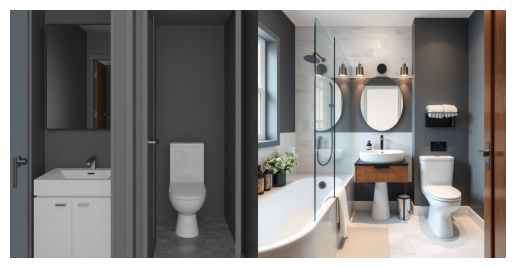

tidy and clean


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 2.  9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 2.  9.2]


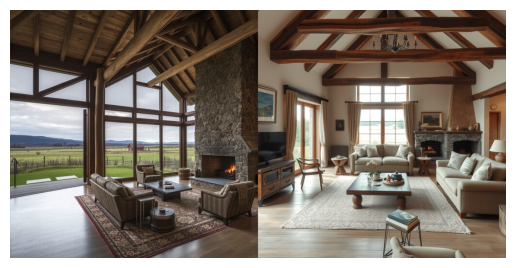

round cylinder


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 4.  7.5]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 1.  9. ]


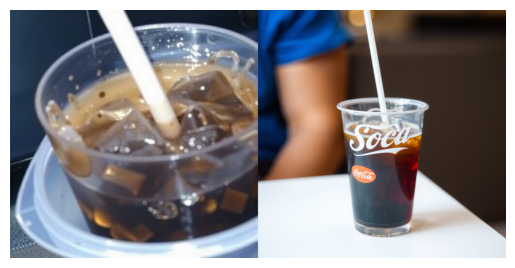

plastic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 6.5 9.1]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.3 4.5 9.1]


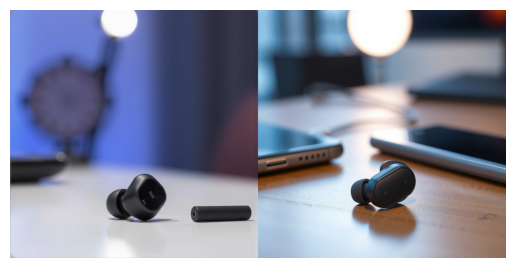

fabric


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 9.8 9.1]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.5 8.8]


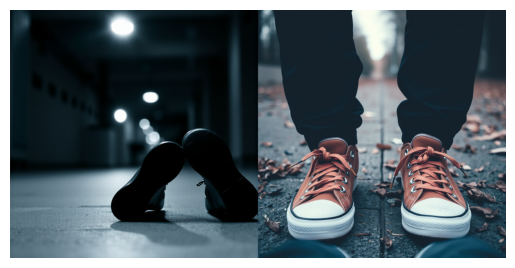

a tie


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 9.8 9.1]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 0.5 9.2]


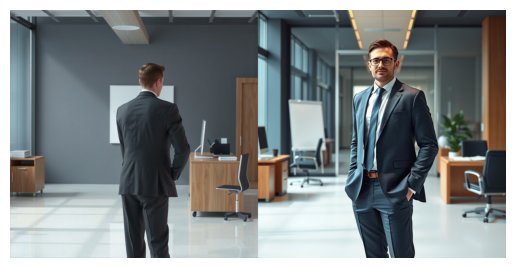

dark liquid


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.5 9. ]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 2.  8. ]


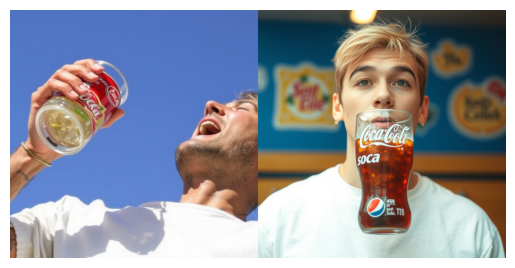

metallic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 8.5 9.1]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 8.8 9.1]


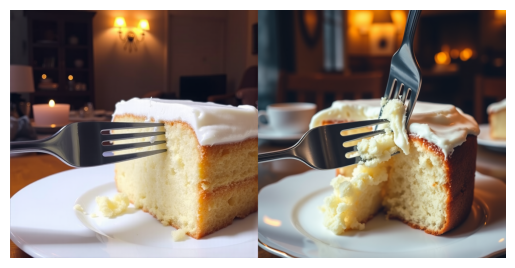

pillows


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 1.  9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 2.  9.1]


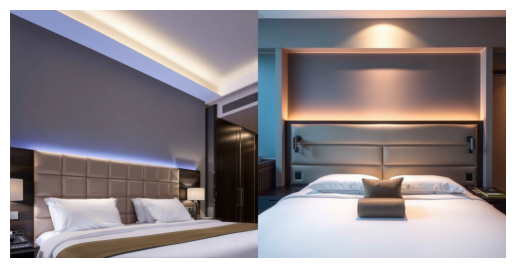

glasses


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.9 9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.8 9.2]


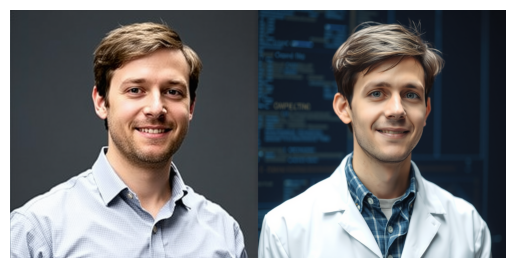

metallic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 3.5 9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 3.5 9.2]


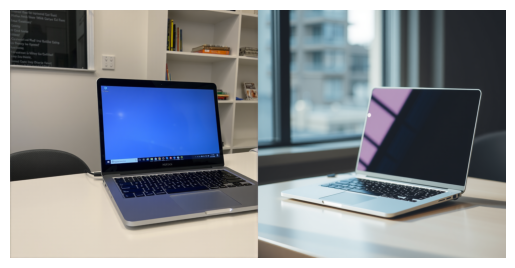

plastic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 9.5 9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 1.  9.2]


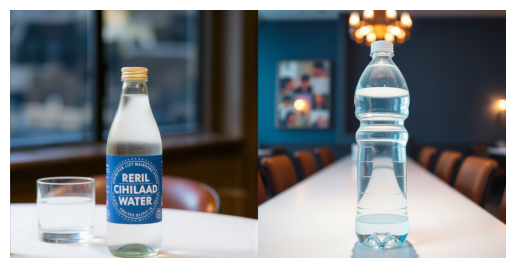

wooden


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[7.5 9.5 8.5]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 9.8 9.4]


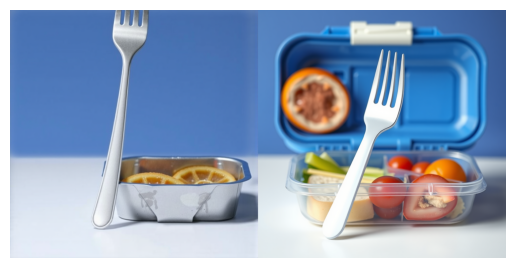

plastic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[7.5 9.5 9. ]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.5 9. ]


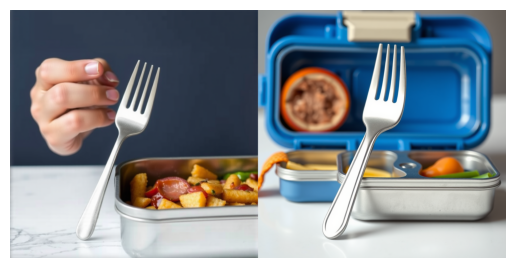

paper box


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 8.5 8.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.8 1.5 9.1]


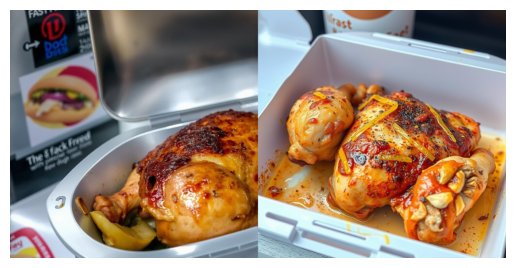

dark color cars


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 8.8 9.1]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 7.8 9.1]


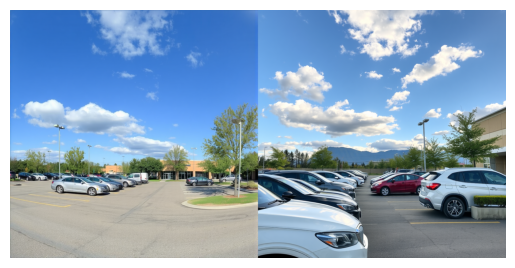

screen lit


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 2.  8.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 1.  9.2]


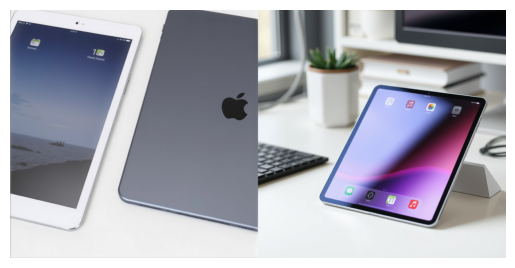

screen unlit


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[7.5 9.5 7. ]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 9.8 9.6]


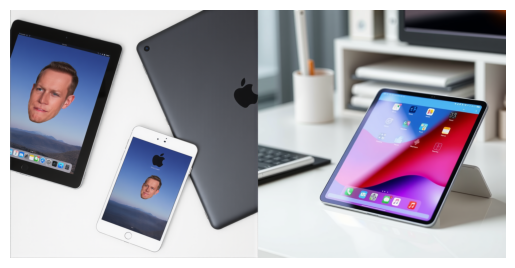

colored


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 9.8 9.2]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.2 2.  9.1]


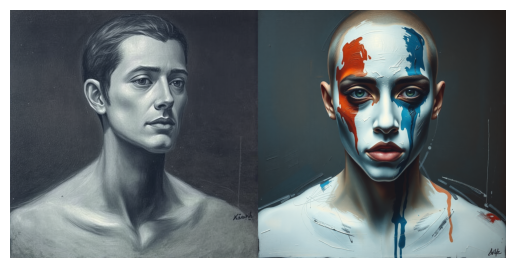

fluffy


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.8 8.8]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[6.5 9.8 8. ]


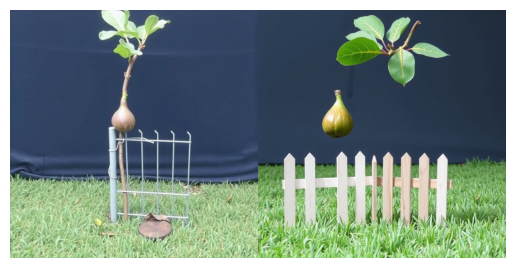

wooden


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 9.8 8.8]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.4 9.8 9.3]


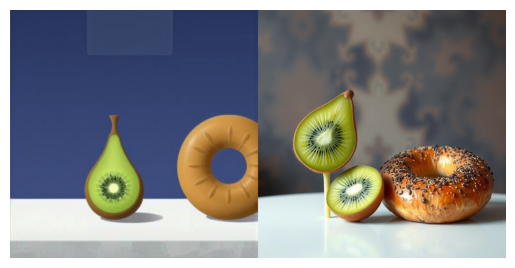

plastic


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[8.5 7.5 9. ]


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


[9.5 6.5 9.2]


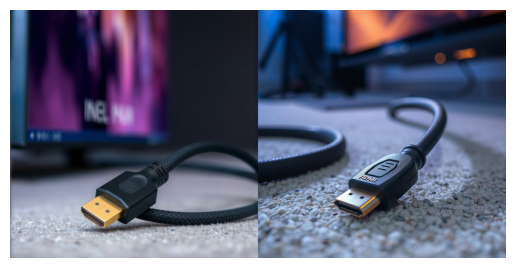

In [28]:
import time
import numpy as np
import cv2
import random
seed = random.randint(0, 10000)
print(seed)
win = 0
total = 0
wandb.init(project="flux")

scores = np.zeros((2, 3))

for i in prompts:
  NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor

  positive_prompt = i["pos"]
  # negative_prompt = "low resolution, blury, low quality, poor details"
  negative_prompt = i["neg"]# + " low resolution, blury, low quality, poor details, downvoted"
  print(negative_prompt)
  image_ours = pipe(
      positive_prompt,
      guidance_scale=0.,
      nag_negative_prompt=negative_prompt,
      nag_scale=4,
      generator=torch.Generator(device="cuda").manual_seed(seed),
      num_inference_steps=5,
      max_sequence_length=256,
  ).images[0]

  res = np.array(ask_gpt(image_ours, positive_prompt, negative_prompt))
  scores[0] += res
  print(res)
  NAGFluxPipeline._set_nag_attn_processor = _set_nag_attn_processor_vanilla

  image_vanilla = pipe(
      positive_prompt,
      guidance_scale=0.,
      nag_negative_prompt=negative_prompt,
      nag_scale=4,
      generator=torch.Generator(device="cuda").manual_seed(seed),
      num_inference_steps=5,
      max_sequence_length=256,
  ).images[0]


  res = np.array(ask_gpt(image_vanilla, positive_prompt, negative_prompt))
  scores[1] += res
  print(res)

  full = cv2.hconcat([np.array(image_ours), np.array(image_vanilla)])
  wandb.log({"img": wandb.Image(full, caption=f"+:{positive_prompt}\n-:{negative_prompt}")})
  pylab.imshow(full)
  pylab.axis('off')
  pylab.show()



In [29]:
# compare is better score is not objective

In [30]:
import pandas as pd

pd.DataFrame(scores, columns=["positive", "negative", "quality"], index=["ours", "vanilla"])

,positive,negative,quality
ours,191.5,168.2,192.7
vanilla,199.8,114.1,199.3
